<a href="https://colab.research.google.com/github/divyansshu/pytorch/blob/main/Pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* 1. Data (prepare and load)
* 2. build model
* 3. fitting the model to data (training)
* 4. making predictions and evaluating a model (inference)
* 5. putting it all together.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

# Data (preparing and loading)

In [2]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

In [3]:
y

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260],
        [0.4400],
        [0.4540],
        [0.4680],
        [0.4820],
        [0.4960],
        [0.5100],
        [0.5240],
        [0.5380],
        [0.5520],
        [0.5660],
        [0.5800],
        [0.5940],
        [0.6080],
        [0.6220],
        [0.6360],
        [0.6500],
        [0.6640],
        [0.6780],
        [0.6920],
        [0.7060],
        [0.7200],
        [0.7340],
        [0.7480],
        [0.7620],
        [0.7760],
        [0.7900],
        [0.8040],
        [0.8180],
        [0.8320],
        [0.8460],
        [0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

In [4]:
len(X), len(y)

(50, 50)

# splitting data into training and testing set

In [5]:
train_split = int(0.8 * len(X))
X_train, y_train, X_test, y_test = X[:train_split], y[:train_split], X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
  '''
  plots training data, testing data and compares predictions
  '''
  plt.figure(figsize=(10,7))

  # plot training data in blue
  plt.scatter(train_data, train_labels, c='b', s=4, label='Training Data')

  # plot test data in green
  plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

  if predictions is not None:
    # plot the predictions if they exist
    plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

  # show the legend
  plt.legend(prop={'size': 14})




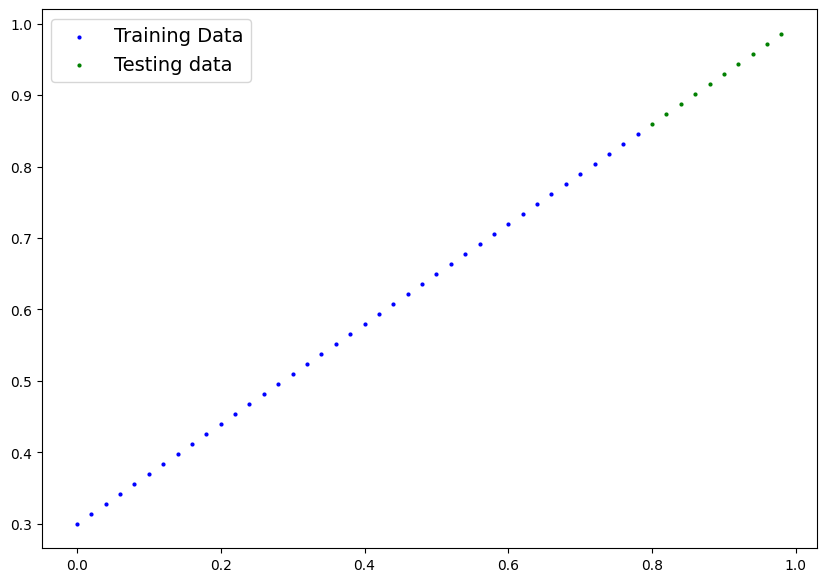

In [7]:
plot_predictions()

# Build a model

In [8]:
# create linear regression model class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  def forward(self, x : torch.Tensor):
    return self.weights * x + self.bias

# checking the contents of our pytorch model

In [9]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

# Making prediction using torch.inference_mode()

In [10]:
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

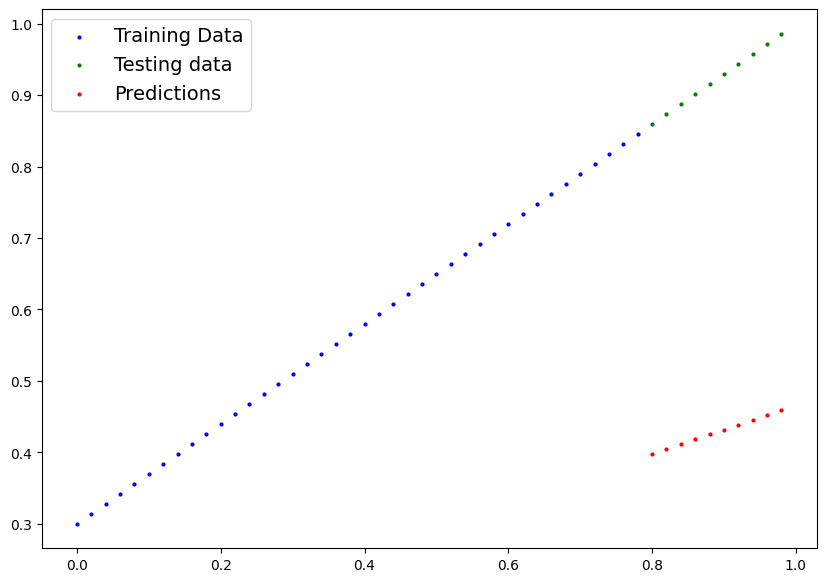

In [11]:
plot_predictions(predictions=y_preds)

# Train model
* loss function
* optimizer

In [12]:
### setup loss function
loss_fn = nn.L1Loss()

## setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

# building a training loop (and a testing loop) in pytorch

0. loop through the data
      1. forward pass - to make predictions on data
      2. calculate the loss (compare forward pass predictions to actual value labels)
      3. optimizer zero grad
      4. loss backward- backward propogation
      5. optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss - gradient descent

In [13]:
epochs = 18

loss_values = []
test_loss_values = []
epochs_count = []

# 0. loop throught the data
for epoch in range(epochs):
  # set the model to training mode
  model_0.train() # set all parameters that requires gradients to requires_grad=True

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate loss
  loss = loss_fn(y_pred, y_train)

  # 3. optimizer zero grad
  optimizer.zero_grad()

  # 4. backpropagation on the loss w.r.t the parameters of the model
  loss.backward()

  # 5. step the optimizer- gradient descent
  optimizer.step()


  # testing
  model_0.eval() # turns off different settings in the model not needed for evaluation/testing (dropout/ batch norm layers)
  with torch.inference_mode(): # turns off gradient tracking

     # forward pass
     test_pred = model_0.forward(X_test)

     # calculate the loss
     test_loss = loss_fn(test_pred, y_test)

     epochs_count.append(epoch)
     loss_values.append(loss)
     test_loss_values.append(test_loss)

     print(f'Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}')

  print(model_0.state_dict())

Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.35982614755630493
OrderedDict({'weights': tensor([0.3757]), 'bias': tensor([0.2288])})
Epoch: 1 | Loss: 0.1976713389158249 | Test Loss: 0.22511616349220276
OrderedDict({'weights': tensor([0.4147]), 'bias': tensor([0.3288])})
Epoch: 2 | Loss: 0.08682452142238617 | Test Loss: 0.1217411532998085
OrderedDict({'weights': tensor([0.4522]), 'bias': tensor([0.3988])})
Epoch: 3 | Loss: 0.04956193268299103 | Test Loss: 0.10394115746021271
OrderedDict({'weights': tensor([0.4722]), 'bias': tensor([0.3988])})
Epoch: 4 | Loss: 0.04610266909003258 | Test Loss: 0.09979012608528137
OrderedDict({'weights': tensor([0.4881]), 'bias': tensor([0.3888])})
Epoch: 5 | Loss: 0.04258420318365097 | Test Loss: 0.08877012133598328
OrderedDict({'weights': tensor([0.5061]), 'bias': tensor([0.3838])})
Epoch: 6 | Loss: 0.03921257331967354 | Test Loss: 0.08461911976337433
OrderedDict({'weights': tensor([0.5220]), 'bias': tensor([0.3738])})
Epoch: 7 | Loss: 0.0357321910

In [14]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

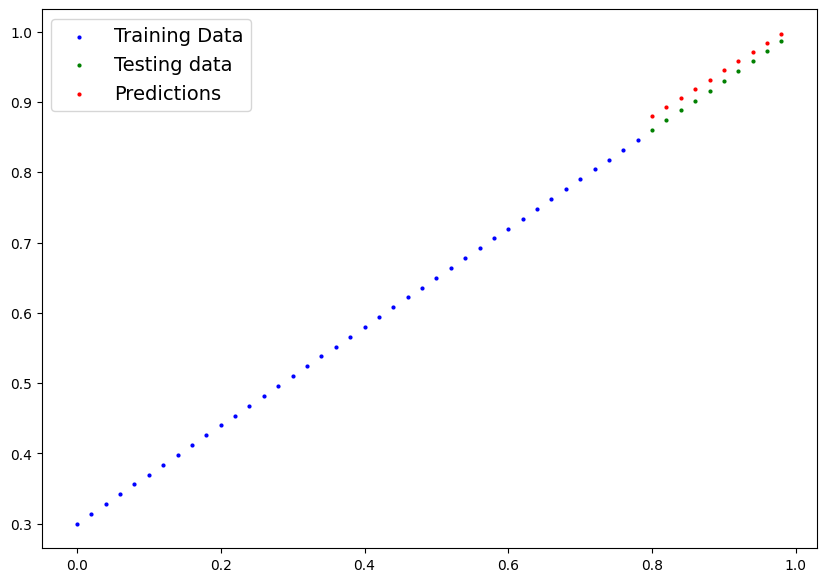

In [15]:
plot_predictions(predictions=y_preds_new)

In [16]:
import numpy as np

In [17]:
loss_values = torch.tensor(loss_values).detach().numpy()
loss_values

/tmp/ipykernel_2945/368350438.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss_values = torch.tensor(loss_values).detach().numpy()


array([0.31288138, 0.19767134, 0.08682452, 0.04956193, 0.04610267,
       0.0425842 , 0.03921257, 0.03573219, 0.03232246, 0.02888019,
       0.02543237, 0.02204191, 0.01907123, 0.01878811, 0.03977372,
       0.07543627, 0.03977372, 0.07543627], dtype=float32)

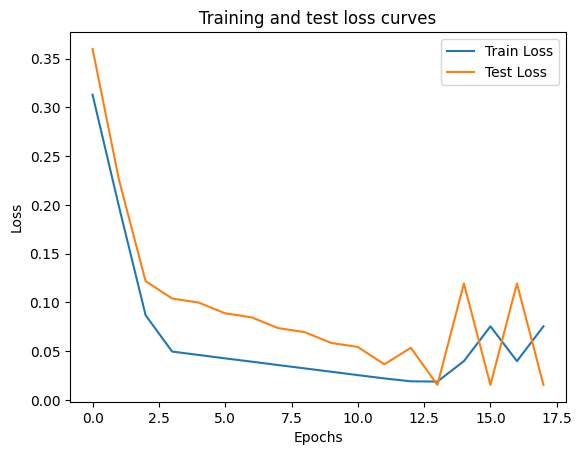

In [18]:
# plot the loss curves
plt.plot(epochs_count, loss_values, label='Train Loss')
plt.plot(epochs_count, test_loss_values, label='Test Loss')
plt.title('Training and test loss curves')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()

# saving model

In [19]:
torch.save(obj = model_0.state_dict(), f='pytorch_workflow.pt') # saving the state_dict() only saves the model learned parameters.

# load model

In [20]:
# Re-instantiate a fresh, empty skeleton of model
load_model = LinearRegressionModel()

# Deserialize the weights file from the disk
saved_parameters = torch.load('pytorch_workflow.pt')

# Inject the weights into our empty skeleton
load_model.load_state_dict(saved_parameters)

<All keys matched successfully>

# Test the loaded model

In [21]:
load_model.eval()

with torch.inference_mode():
  load_model_preds = load_model(X_test)

In [22]:
load_model_preds == y_preds_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# Exercises

Create a straight line dataset using the linear regression formula (weight * X + bias).

In [23]:
weight = 0.3
bias = 0.9
X = torch.rand(1, 100)
X

tensor([[0.9408, 0.1332, 0.9346, 0.5936, 0.8694, 0.5677, 0.7411, 0.4294, 0.8854,
         0.5739, 0.2666, 0.6274, 0.2696, 0.4414, 0.2969, 0.8317, 0.1053, 0.2695,
         0.3588, 0.1994, 0.5472, 0.0062, 0.9516, 0.0753, 0.8860, 0.5832, 0.3376,
         0.8090, 0.5779, 0.9040, 0.5547, 0.3423, 0.6343, 0.3644, 0.7104, 0.9464,
         0.7890, 0.2814, 0.7886, 0.5895, 0.7539, 0.1952, 0.0050, 0.3068, 0.1165,
         0.9103, 0.6440, 0.7071, 0.6581, 0.4913, 0.8913, 0.1447, 0.5315, 0.1587,
         0.6542, 0.3278, 0.6532, 0.3958, 0.9147, 0.2036, 0.2018, 0.2018, 0.9497,
         0.6666, 0.9811, 0.0874, 0.0041, 0.1088, 0.1637, 0.7025, 0.6790, 0.9155,
         0.2418, 0.1591, 0.7653, 0.2979, 0.8035, 0.3813, 0.7860, 0.1115, 0.2477,
         0.6524, 0.6057, 0.3725, 0.7980, 0.8399, 0.1374, 0.2331, 0.9578, 0.3313,
         0.3227, 0.0162, 0.2137, 0.6249, 0.4340, 0.1371, 0.5117, 0.1585, 0.0758,
         0.2247]])

In [24]:
X.shape

torch.Size([1, 100])

In [25]:
y = weight * X + bias
y

tensor([[1.1822, 0.9400, 1.1804, 1.0781, 1.1608, 1.0703, 1.1223, 1.0288, 1.1656,
         1.0722, 0.9800, 1.0882, 0.9809, 1.0324, 0.9891, 1.1495, 0.9316, 0.9808,
         1.0076, 0.9598, 1.0642, 0.9018, 1.1855, 0.9226, 1.1658, 1.0750, 1.0013,
         1.1427, 1.0734, 1.1712, 1.0664, 1.0027, 1.0903, 1.0093, 1.1131, 1.1839,
         1.1367, 0.9844, 1.1366, 1.0768, 1.1262, 0.9586, 0.9015, 0.9920, 0.9349,
         1.1731, 1.0932, 1.1121, 1.0974, 1.0474, 1.1674, 0.9434, 1.0594, 0.9476,
         1.0963, 0.9983, 1.0960, 1.0187, 1.1744, 0.9611, 0.9605, 0.9605, 1.1849,
         1.1000, 1.1943, 0.9262, 0.9012, 0.9326, 0.9491, 1.1108, 1.1037, 1.1746,
         0.9725, 0.9477, 1.1296, 0.9894, 1.1410, 1.0144, 1.1358, 0.9335, 0.9743,
         1.0957, 1.0817, 1.0118, 1.1394, 1.1520, 0.9412, 0.9699, 1.1873, 0.9994,
         0.9968, 0.9049, 0.9641, 1.0875, 1.0302, 0.9411, 1.0535, 0.9475, 0.9227,
         0.9674]])

In [26]:
X = X.squeeze()
X.shape

torch.Size([100])

In [27]:
y = y.squeeze()
y.shape

torch.Size([100])

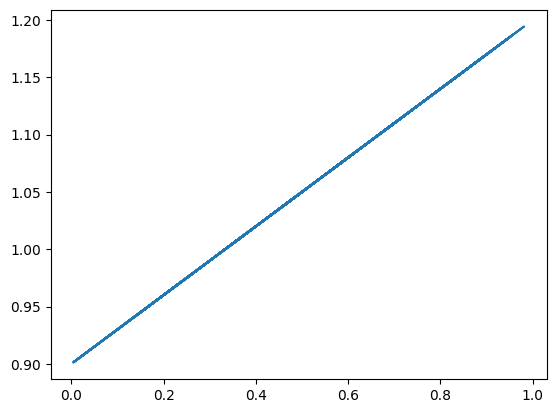

In [28]:
plt.plot(X, y)

# 1. split the data into training and testing

In [29]:
train_split = int(len(X) * 0.8)
X_train, y_train, X_test, y_test = X[:train_split], y[:train_split], X[train_split:], y[train_split:]

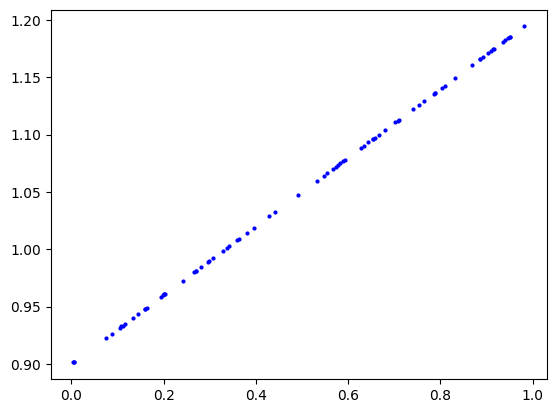

In [30]:
plt.scatter(X_train, y_train, c='b', s=4, label='Training Data')

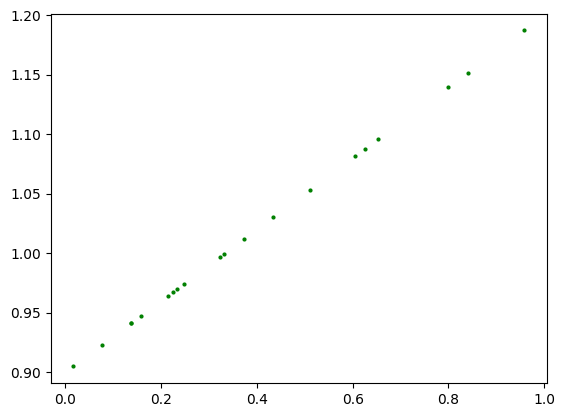

In [31]:
plt.scatter(X_test, y_test, c='g', s=4, label='Testing Data')

# 2. Build a pytorch model by subclassing nn.Module

In [32]:
class LinearRegressionModel_v2(nn.Module):
  def __init__(self):
    super().__init__()

    # self.weights = nn.Parameter(torch.randn(1,requires_grad=True, dtype=torch.float))

    # self.bias = nn.Parameter(torch.randn(1,requires_grad=True, dtype=torch.float))

    self.linear_layer = nn.Linear(in_features=1,out_features=1)

    def forward(self, x):
      # return self.weights * x + self.bias
      return self.linear_layer(x)

lr_model = LinearRegressionModel()
lr_model.state_dict()

OrderedDict([('weights', tensor([-3.5945])), ('bias', tensor([0.0192]))])

# 3. Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.

In [33]:
loss_fn2 = nn.L1Loss()
optimizer2 = torch.optim.SGD(params=lr_model.parameters(), lr = 0.01)

In [50]:
# Training loop
epochs = 300
for epoch in range(epochs):

  lr_model.train()

  # 1 forward pass
  train_preds = lr_model(X_train)

  # 2 calculate loss
  train_loss = loss_fn2(train_preds, y_train)

  # 3 zero grad optimizer - reset gradients
  optimizer.zero_grad()

  # 4 backward() - backpropogation - Calculate the gradients (slopes) for each parameter
  train_loss.backward()

  # 4 step optimizer- updates parameters
  optimizer.step()

  ### Testing
  lr_model.eval()
  with torch.inference_mode():
    # forward pass
    test_preds = lr_model(X_test)

    # calculate loss
    test_loss = loss_fn2(test_preds, y_test)

    if epoch % 20 == 0:
      print(f'Epoch: {epoch} | Train_loss: {train_loss} | Test_loss: {test_loss}')




Epoch: 0 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 20 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 40 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 60 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 80 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 100 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 120 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 140 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 160 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 180 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 200 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 220 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 240 | Train_loss: 2.8712716102600098 | Test_loss: 2.418210506439209
Epoch: 260 | Train_loss: 2.8712

# 4 Make predictions with the trained model on the test data.

In [51]:
lr_model.eval()
with torch.inference_mode():
  y_preds = lr_model(X_test)
print(y_preds)

tensor([-0.8711, -2.3260, -2.1580, -1.3199, -2.8494, -2.9999, -0.4748, -0.8186,
        -3.4237, -1.1716, -1.1409, -0.0391, -0.7489, -2.2270, -1.5409, -0.4735,
        -1.8202, -0.5504, -0.2533, -0.7884])


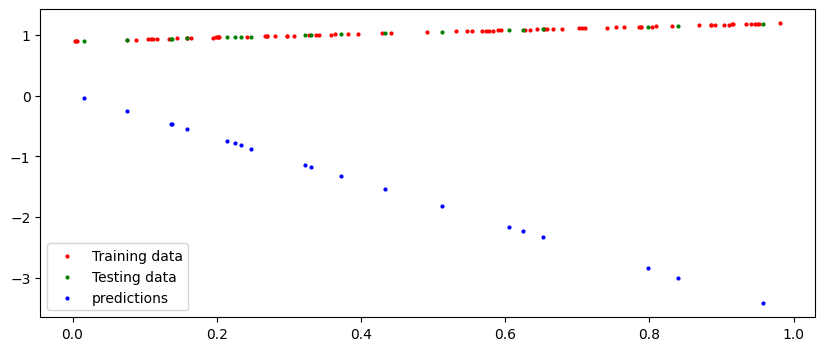

In [52]:
plt.figure(figsize=(10,4))

plt.scatter(X_train, y_train, c='r',s=4, label='Training data')
plt.scatter(X_test, y_test, c='g',s=4, label='Testing data')
plt.scatter(X_test, y_preds, c='b', s=4, label='predictions')

plt.legend()